# Statistikprojekt *NAME*
Für das Modul W.EDS_VSSTAT02.H2581

Betreut durch Dr. Curdin Derungs

Verfasst von Andreas Jäggi

## Vorbereitungen für die Analyse

In [3]:
# Alle nötigen Bibliotheken laden:

#pip install statsmodel pandas numpy
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

In [4]:
# Laden des Datensatzes:
data_heart = pd.read_csv('heart.csv')
# Anzeigen der ersten Zeilen des Datensatzes
data_heart.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Hier sind die Spalten kurz erklärt:
- age       = Das Alter der Person in Jahren
- sex       = Das Geschlecht der Person (1=Männlich, 0=Weiblich)
- cp        = Brustschmerztyp (ChestPain) dabei ist es ein Wert von 1 bis 4 (1=typischer Schmerz, 2=atypischer Schmerz, 3=nicht-angiöser Schmerz, 4=asyptomatisch)
- trestbps  = Ruheblutdruck, in mm Hg angegeben, dient als Kontrollvariable
- chol      = Cholesterin im Blut, in mg/dl angegeben
- fbs       = Nüchternblutzucker (1=grösser 120mg/dl, 0=gleich oder kleiner als 120mg/dl)
- restecg   = Ruhe EKG, Werte von 0, 1 oder 2 (0=Normal, 1= ST-T Wellenanomalie, 2=Hypertrophie)
- thalach   = Maximal erreichte Herzfrequenz
- exang     = Wurde bei Sport/Anstrengung eine Brustenge ausgelöst? (1= Ja, 0= Nein)
- oldpeak   = Ein wert aus dem EKG, zeigt an, wie schnell die Kurve nach dem Sport sinkt (Höherer Wert = schneller)
- slope     = Zeigt die Steigung des ST-Segments bei maximaler Belastung
- ca        = Anzahl sichtbarer Gefässe (von 0 bis 3), je mehr sichtbar = besser
- thal      = Thalassämie, ist eine Bluterkrankung,
- target    = Unsere Zielvariable, gibt an ob eine Herzerkrankung vorliegt oder nicht (1= Gesund, 0=Krank)


## Erstellen des Modells

In [5]:
# --------------------------------------------------------------------------------
# MODELLIERUNG (GLM)
# --------------------------------------------------------------------------------

# Formel:
# 1. Kontrolle auf Blutdruck (trestbps).
# 2. Das Geschlecht wird mit ALLEN Risikofaktoren interagiert.
# 3. 'cp' (Brustschmerz) wird weggelassen, da es ein Symptom ist.

formula = 'target ~ sex * (age + chol + trestbps)'

# Es werden Haupteffekte und Interaktionen berechnet.

print(f"Verwendete Formel: {formula}")

# Modell anpassen (Logistische Regression -> Family Binomial)
model = smf.glm(formula=formula, data=data_heart, family=sm.families.Binomial())
result = model.fit()

Verwendete Formel: target ~ sex * (age + chol + trestbps)


In [6]:
print(result.summary())

# Odds Ratios berechnen

params = result.params
conf = result.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
odds_ratios = np.exp(conf)

print("\n--- Odds Ratios (Chancenverhältnisse) ---\n")
print(odds_ratios)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                 1025
Model:                            GLM   Df Residuals:                     1017
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -600.61
Date:                Sun, 18 Jan 2026   Deviance:                       1201.2
Time:                        11:23:33   Pearson chi2:                     999.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1924
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        9.7947      1.413      6.930   

## Plots für die Präsentation

C:\Users\jaegg\AppData\Local\Temp\ipykernel_10324\2008770199.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_vis, palette=my_palette)


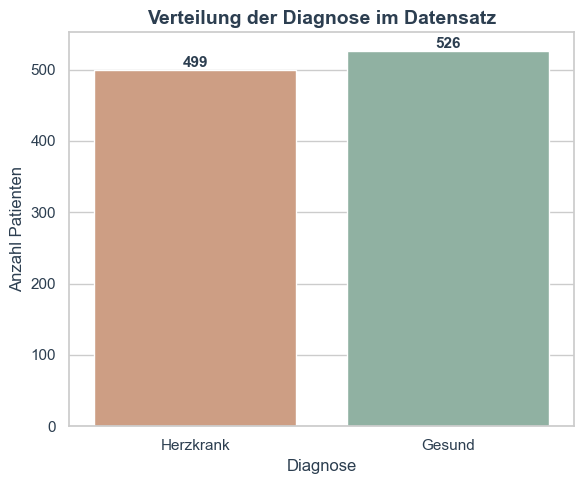

C:\Users\jaegg\AppData\Local\Temp\ipykernel_10324\2008770199.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='age', data=df_vis, palette=my_palette)


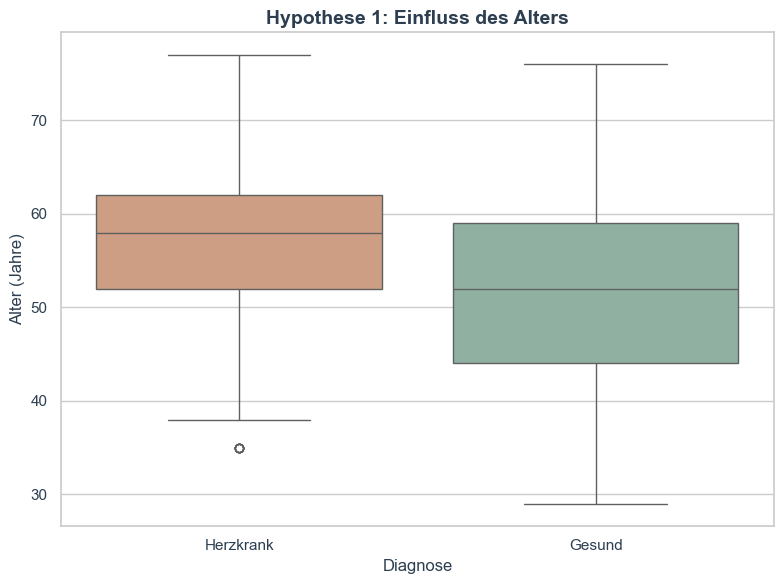

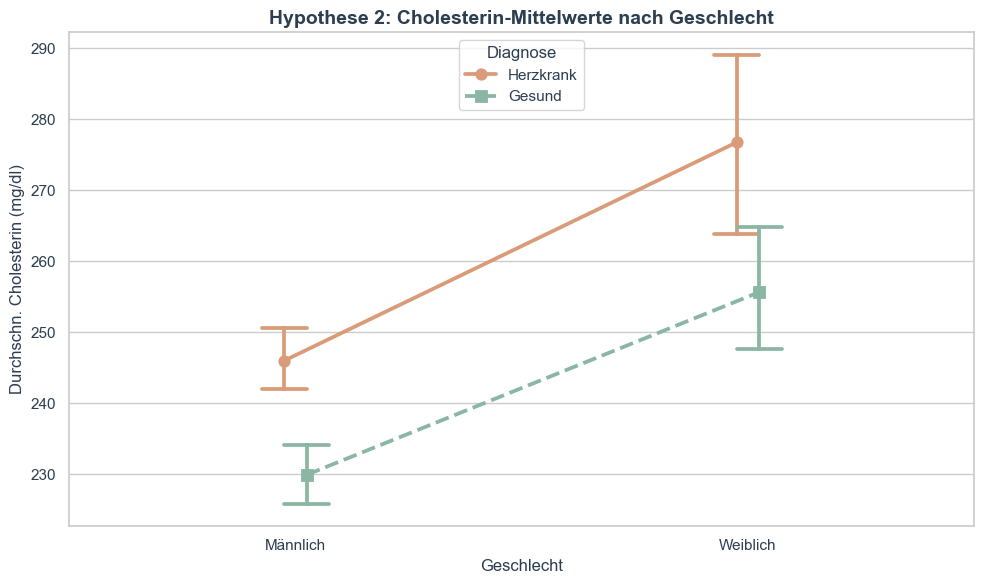

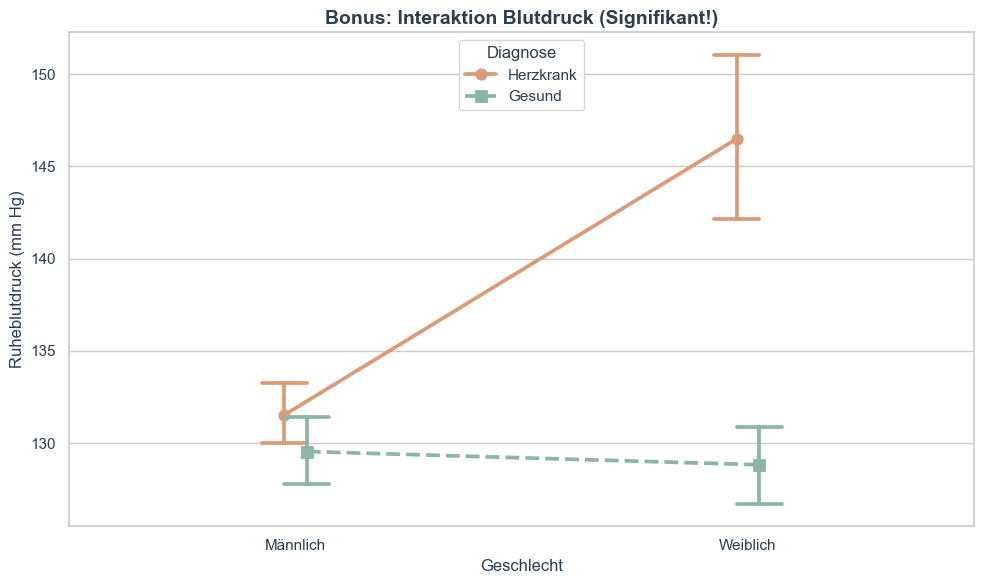

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --------------------------------------------------------------------------------
# 1. SETUP & FARBSCHEMA (Passend zur Präsentation)
# --------------------------------------------------------------------------------

# Deine Daten laden & vorbereiten
df_vis = data_heart.copy()
# Mapping sicherstellen (0=Krank, 1=Gesund - gemäss deiner Analyse)
df_vis['target'] = df_vis['target'].map({0: 'Herzkrank', 1: 'Gesund'})
df_vis['sex'] = df_vis['sex'].map({1: 'Männlich', 0: 'Weiblich'})

# --- DEIN FARBSCHEMA ---
colors = {
    'Gesund': '#8AB6A3',     # Salbei-Grün
    'Herzkrank': '#D99B78',  # Terrakotta-Orange
    'Text': '#2C3E50'        # Dunkles Blau-Grau für Schrift
}

my_palette = {'Gesund': colors['Gesund'], 'Herzkrank': colors['Herzkrank']}

# Globales Design setzen
sns.set_theme(style="whitegrid")
plt.rcParams['text.color'] = colors['Text']
plt.rcParams['axes.labelcolor'] = colors['Text']
plt.rcParams['xtick.color'] = colors['Text']
plt.rcParams['ytick.color'] = colors['Text']

# --------------------------------------------------------------------------------
# PLOT 1: AUFTEILUNG (Countplot)
# --------------------------------------------------------------------------------
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='target', data=df_vis, palette=my_palette)

plt.title('Verteilung der Diagnose im Datensatz', fontsize=14, fontweight='bold', color=colors['Text'])
plt.xlabel('Diagnose', fontsize=12)
plt.ylabel('Anzahl Patienten', fontsize=12)

# Zahlen auf die Balken schreiben
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold', color=colors['Text'])

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# PLOT 2 (H1): ALTER (Boxplot)
# --------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='age', data=df_vis, palette=my_palette)

plt.title('Hypothese 1: Einfluss des Alters', fontsize=14, fontweight='bold', color=colors['Text'])
plt.xlabel('Diagnose', fontsize=12)
plt.ylabel('Alter (Jahre)', fontsize=12)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# PLOT 3 (H2): CHOLESTERIN INTERAKTION (Pointplot statt Violinplot)
# --------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))


sns.pointplot(x='sex', y='chol', hue='target', data=df_vis, 
              dodge=True, markers=['o', 's'], capsize=.1, linestyles=["-", "--"],
              palette=my_palette)

plt.title('Hypothese 2: Cholesterin-Mittelwerte nach Geschlecht', fontsize=14, fontweight='bold', color=colors['Text'])
plt.xlabel('Geschlecht', fontsize=12)
plt.ylabel('Durchschn. Cholesterin (mg/dl)', fontsize=12)
plt.legend(title='Diagnose', loc='upper center')

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# PLOT 4 (BONUS): BLUTDRUCK (Pointplot)
# --------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.pointplot(x='sex', y='trestbps', hue='target', data=df_vis, 
              dodge=True, markers=['o', 's'], capsize=.1, linestyles=["-", "--"],
              palette=my_palette)

plt.title('Bonus: Interaktion Blutdruck (Signifikant!)', fontsize=14, fontweight='bold', color=colors['Text'])
plt.xlabel('Geschlecht', fontsize=12)
plt.ylabel('Ruheblutdruck (mm Hg)', fontsize=12)
plt.legend(title='Diagnose', loc='upper center')

plt.tight_layout()
plt.show()